# 스마트 플래시카드 코치 (Smart Flashcard Coach) 설계 문서

## 1. 개요
* **이름**: 스마트 플래시카드 코치 (Smart Flashcard Coach)
* **목적**: 학습자료를 바탕으로 플래시카드를 자동 생성하고, 퀴즈 테스트를 진행한 뒤 채점 결과 리포트를 피드백하여 암기 효율성을 향상시킵니다.

## 2. 핵심 기능
1. **학습 자료 파싱 (parse_material)**: 원본 자료에서 핵심 키워드 및 개념 리스트를 추출합니다.
2. **플래시카드 생성 (generate_flashcards)**: 추출된 개념 리스트를 기반으로 Q&A 형태의 학습용 카드 세트를 구축합니다.
3. **대화형 퀴즈 출제 (quiz_interrupt)**: 사용자에게 문제 세트를 전달하고 답변을 제출할 때까지 대기(Interrupt)합니다.
4. **퀴즈 채점 및 피드백 (grade_quiz)**: 사용자의 답변과 정답을 매칭해 평가 리포트를 산출합니다.

## 3. 그래프 구조
```
[START] -> parse_material -> generate_flashcards -> quiz_interrupt -> grade_quiz -> [END]
```

In [1]:
from typing import TypedDict, List, Dict, Any
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt

# 1. State 정의
class State(TypedDict):
    learning_material: str
    concepts: List[str]
    flashcards: List[Dict[str, str]]
    user_answers: List[str]
    evaluation_report: str

d:\dev\study\ai-agents-class\demo-project\.venv\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
# 2. 노드 정의
def parse_material(state: State) -> Dict[str, Any]:
    print("--- [Node] parse_material ---")
    material = state.get("learning_material", "")
    # 간단한 라인 분리 예시 (실제 구현 시 LLM이나 정규표현식 활용 가능)
    concepts = [f"Concept: {line.strip()}" for line in material.split("\n") if line.strip()]
    return {"concepts": concepts}

def generate_flashcards(state: State) -> Dict[str, Any]:
    print("--- [Node] generate_flashcards ---")
    concepts = state.get("concepts", [])
    flashcards = []
    for i, concept in enumerate(concepts):
        flashcards.append({
            "id": i + 1,
            "question": f"What is the definition of '{concept}'?",
            "answer": f"This is the description for '{concept}'."
        })
    return {"flashcards": flashcards}

def quiz_interrupt(state: State) -> Dict[str, Any]:
    print("--- [Node] quiz_interrupt ---")
    flashcards = state.get("flashcards", [])
    # 사용자 입력을 받기 위해 interrupt 호출
    answer = interrupt({
        "questions": [card["question"] for card in flashcards],
        "instruction": "Please provide answers to the questions in 'user_answers'."
    })
    return {
        "user_answers": answer.get("user_answers", [])
    }

def grade_quiz(state: State) -> Dict[str, Any]:
    print("--- [Node] grade_quiz ---")
    flashcards = state.get("flashcards", [])
    user_answers = state.get("user_answers", [])
    
    report = "### Quiz Evaluation Report\n"
    for i, card in enumerate(flashcards):
        u_ans = user_answers[i] if i < len(user_answers) else "No Answer"
        report += f"\nQ{card['id']}: {card['question']}\n- Your Answer: {u_ans}\n- Correct Answer: {card['answer']}\n"
    
    return {"evaluation_report": report}

In [3]:
# 3. 그래프 연결
graph_builder = StateGraph(State)

graph_builder.add_node("parse_material", parse_material)
graph_builder.add_node("generate_flashcards", generate_flashcards)
graph_builder.add_node("quiz_interrupt", quiz_interrupt)
graph_builder.add_node("grade_quiz", grade_quiz)

graph_builder.add_edge(START, "parse_material")
graph_builder.add_edge("parse_material", "generate_flashcards")
graph_builder.add_edge("generate_flashcards", "quiz_interrupt")
graph_builder.add_edge("quiz_interrupt", "grade_quiz")
graph_builder.add_edge("grade_quiz", END)

# 메모리 세이버와 함께 컴파일
from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()
graph = graph_builder.compile(checkpointer=memory)

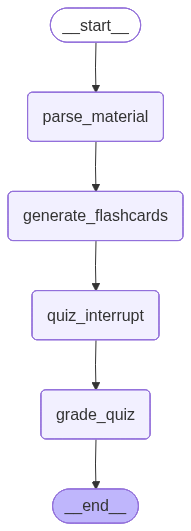

In [4]:
graph